## Figure 9

Note: This notebook requires the following simulation outputs (see `simulations.md` for run commands):

- `out/fig9_motor/`: M1 motor learning networks, 10 seeds

Experimental data in panels d, f, h are digitized from Ren et al. (2022).

In [146]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["JAX_PLATFORM_NAME"] = "cpu"

from pathlib import Path

import numpy as np
import jax
import jax.numpy as jnp

import matplotlib as mpl
import matplotlib.pyplot as plt
import spiffyplots
from spiffyplots import MultiPanel

mpl.style.use('spiffy')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",})

from bcp.analysis import HydraRunOutput
from bcp.data.experiments import RenMotorLearning
from bcp.utils.plotting import add_scalebar

jax.config.update("jax_threefry_partitionable", False)

repo_root = next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "bcp").is_dir())

#### Directory setup

In [147]:
run_dir = repo_root / "out" / "fig9_motor"

fig9_dir = repo_root / "figures" / "fig9"
fig9_dir.mkdir(parents=True, exist_ok=True)

#### Plotting parameters

In [148]:
cm = 1 / 2.54

singlecolwidth = 8.5 * cm
onehalfcolwidth = 11.4 * cm
doublecolwidth = 17.4 * cm

color_exc = '#CD2027'
color_inh2 = '#0077B8'
color_inh1 = '#57CAF1'
color_closedloop = '#F49F1E'
color_inputs = '#808285'
color_lever = '#A66D3A'
color_lever_light = '#CA9668'

linewidth = 1.0

panelsize_performance = (3.6*cm, 3.0*cm)
panelsize_other = (3.2*cm, 3.0*cm)

### Panels d, f, h: Ren et al. (2022) data

In [149]:
# Fig 1B: % correct trials per session (mean, upper SEM bound)
perf_mean = np.array([52.08768267223382, 61.586638830897705, 71.9206680584551, 77.76617954070981, 82.35908141962422,
                      83.29853862212944, 86.32567849686848, 85.17745302713988, 86.74321503131524, 89.77035490605428,
                      89.87473903966597, 89.5615866388309, 91.33611691022965, 93.1106471816284, 94.0501043841336,
                      94.67640918580376, 93.1106471816284, 93.0062630480167, 92.58872651356994, 93.94572025052192,
                      94.98956158663883, 93.73695198329854])
perf_sem = np.array([54.80167014613779, 65.34446764091858, 75.5741127348643, 81.3152400835073, 85.38622129436325,
                     86.32567849686848, 89.14405010438414, 87.78705636743214, 89.5615866388309, 92.17118997912317,
                     92.48434237995825, 92.06680584551148, 93.52818371607515, 94.98956158663883, 95.82463465553236,
                     96.13778705636743, 95.51148225469728, 95.82463465553236, 94.67640918580376, 96.03340292275574,
                     96.3465553235908, 96.03340292275574]) - perf_mean
sessions = np.arange(1, len(perf_mean) + 1)
naive, early, middle = 2.5, 8.5, 16.5  # stage boundaries (sessions)

# Fig 4D / 4I: mean dF/F per stage (mean, upper SEM bound)
stages = ['Naive', 'Early', 'Middle', 'Late']
vip_mean = np.array([0.30800627943485087, 0.17189952904238617, 0.12810047095761382, 0.10502354788069074])
vip_sem = np.array([0.3204866562009419, 0.1801412872841444, 0.13587127158555729, 0.1118524332810047]) - vip_mean
som_mean = np.array([0.06716129032258064, 0.11612903225806451, 0.11690322580645161, 0.11825806451612902])
som_sem = np.array([0.07529032258064516, 0.12696774193548388, 0.1290967741935484, 0.12929032258064516]) - som_mean

# Fig 4E / 4I histograms: late - naive dF/F (bin centres, fraction [%])
x_vip_hist = np.array([-1.467680608365019, -1.3536121673003803, -1.2623574144486693, -1.1634980988593155, -1.0570342205323193, -0.9581749049429658, -0.8593155893536122, -0.752851711026616, -0.6539923954372624, -0.5551330798479088, -0.4486692015209126, -0.34980988593155904, -0.24334600760456282, -0.15209125475285168, -0.04562737642585546, 0.04562737642585546, 0.14448669201520925, 0.2433460076045626, 0.3422053231939164, 0.44106463878326974, 0.5323193916349811, 0.6311787072243344, 0.7300380228136882, 0.8136882129277567, 0.8897338403041823, 0.9809885931558937, 1.0570342205323193, 1.1406844106463878])
y_vip_hist = np.array([0.19047619047619047, 0.2857142857142857, 0.23809523809523808, 0.19047619047619047, 0.8571428571428571, 1, 1.5714285714285714, 1.6666666666666665, 2.8095238095238093, 4.19047619047619, 6, 7.238095238095237, 12.19047619047619, 18.904761904761905, 21.619047619047617, 11.38095238095238, 4.142857142857142, 1.5238095238095237, 1.5714285714285714, 0.42857142857142855, 0.23809523809523808, 0.23809523809523808, 0, 0, 0, 0, 0.14285714285714285, 0.23809523809523808])
x_som_hist = np.array([-0.8423423423423424, -0.7432432432432432, -0.6441441441441442, -0.545045045045045, -0.44594594594594594, -0.34684684684684686, -0.2432432432432432, -0.14414414414414412, -0.0495495495495496, 0.05855855855855863, 0.15315315315315314, 0.25225225225225234, 0.3558558558558558, 0.45495495495495497, 0.5585585585585586, 0.6531531531531531, 0.7567567567567568, 0.8468468468468469])
y_som_hist = np.array([0.600375234521576, 0, 0.45028142589118203, 0.600375234521576, 1.050656660412758, 1.200750469043152, 2.476547842401501, 6.604127579737336, 19.28705440900563, 32.4953095684803, 17.86116322701689, 6.75422138836773, 2.176360225140713, 2.476547842401501, 0.825515947467167, 1.275797373358349, 0.300187617260788, 0])

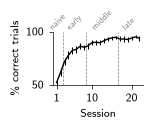

In [150]:
fig, ax = plt.subplots(1, 1, figsize=panelsize_performance)
ax.errorbar(sessions, perf_mean, yerr=perf_sem, fmt='-', color='black', markersize=2, capsize=0,
            elinewidth=0.75, linewidth=1)
ax.set_xlim(0, sessions[-1] + 1)
ax.set_xticks([1, 10, 20])
ax.set_xticklabels(['1', '10', '20'])
ax.set_xlabel('Session')
ax.set_ylim(50, 100)
ax.set_yticks([50, 100])
ax.set_yticklabels(['50', '100'])
ax.set_ylabel(r'\% correct trials')
for boundary in [naive, early, middle]:
    ax.axvline(boundary, color='gray', linestyle='--', linewidth=0.5)
for x, label in [(naive / 2, 'naive'), ((early - naive) / 2 + naive, 'early'),
                 ((middle - early) / 2 + early, 'middle'), ((sessions[-1] - middle) / 2 + middle, 'late')]:
    ax.text(x, 100, label, ha='center', va='bottom', fontsize=6, rotation=45, color='gray')

plt.savefig(fig9_dir / 'd_data_performance.pdf', bbox_inches='tight')
plt.show()

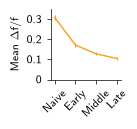

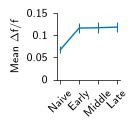

In [151]:
for name, mean, sem, color, ylim, yticks in [
        ('h_data_vip', vip_mean, vip_sem, color_closedloop, (0, 0.35), [0, 0.1, 0.2, 0.3]),
        ('f_data_som', som_mean, som_sem, color_inh2, (0, 0.15), [0, 0.05, 0.1, 0.15])]:
    fig, ax = plt.subplots(1, 1, figsize=panelsize_other)
    ax.errorbar(stages, mean, yerr=sem, fmt='-', color=color, markersize=2, capsize=0, elinewidth=0.75, linewidth=1)
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{t:g}' for t in yticks])
    ax.set_ylabel(r'Mean $\Delta$f/f')
    ax.set_xlim(-0.2, 3.2)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(stages, rotation=45)

    plt.savefig(fig9_dir / f'{name}.pdf', bbox_inches='tight')
    plt.show()

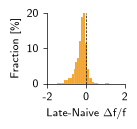

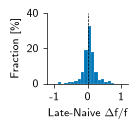

In [152]:
for name, x_hist, y_hist, color, xlim, xticks, ymax in [
        ('h_data_vip_hist', x_vip_hist, y_vip_hist, color_closedloop, (-2, 2), [-2, 0, 2], 20),
        ('f_data_som_hist', x_som_hist, y_som_hist, color_inh2, (-1.2, 1.2), [-1, 0, 1], 40)]:
    # digitized bin centres are uneven; redraw on an even grid
    centres = np.linspace(x_hist.min(), x_hist.max(), len(x_hist))
    bin_width = (x_hist.max() - x_hist.min()) / (len(x_hist) - 1)

    fig, ax = plt.subplots(1, 1, figsize=panelsize_other)
    ax.bar(centres, y_hist, width=bin_width, alpha=1.0, color=color, edgecolor='white', linewidth=0.1)
    ax.vlines(0, 0, ymax, color='black', linestyle='--', linewidth=0.5)
    ax.set_xlabel(r'Late-Naive $\Delta$f/f')
    ax.set_ylabel(r'Fraction [\%]')
    ax.set_xlim(*xlim)
    ax.set_ylim(0, ymax)
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(t) for t in xticks])
    ax.set_yticks([0, ymax / 2, ymax])
    ax.set_yticklabels([f'{t:g}' for t in [0, ymax / 2, ymax]])

    plt.savefig(fig9_dir / f'{name}.pdf', bbox_inches='tight')
    plt.show()

### Load runs

In [153]:
EXAMPLE_SEED = 1
LEVER_THRESHOLD = -0.55
MOVEMENT_WINDOW = slice(2000, 4000)  # 2-4 s after trial start (1 ms steps)
TRIALS_PER_BIN = 20

In [154]:
# per network: time-averaged Type 2 activity and |feedback| during movement, [recordings, inh neurons]
i2_act, mean_fb, lever_minimums = [], [], []
for run_path in sorted(p for p in run_dir.iterdir() if p.is_dir()):
    try:
        r = HydraRunOutput(run_path).load_pickle('results.pkl')
    except Exception as e:
        print(f"Error loading {run_path}: {e}")
        continue
    i2_act.append(r['CL_rI'][:, MOVEMENT_WINDOW].mean(1))
    mean_fb.append(np.abs(r['fb'][:, MOVEMENT_WINDOW]).mean(1))
    lever_minimums.append(r['lever_minimums'])
    if run_path.name == f"seed{EXAMPLE_SEED}":
        X_TRIALS = r['rec_iters']
        motor_before, motor_after = r['CL_uOut'][0], r['CL_uOut'][-1]
    del r

i2_act, mean_fb, lever_minimums = np.stack(i2_act), np.stack(mean_fb), np.stack(lever_minimums)
print('networks:', len(lever_minimums))

networks: 10


### Panel b: example inputs, motor command and lever trace

In [155]:
figsize_inputs = (2.3*cm, 2.5*cm)
figsize_targets = (3.2*cm, 2.2*cm)
nb_inputs = 4

In [156]:
# illustration only: a separate task instance (inputs and target shape)
task = RenMotorLearning(N_sines=5, N=10, T=10, t_cue=2, T_leverpress=2.0, dt=1e-3, noise=True,
                        noise_tau=0.5, noise_mu=0.0, noise_sigma=0.1, tau_rise=30e-3, tau_decay=500e-3)
inputs, motor_target = task.simulate(key=jax.random.PRNGKey(0))
lever_target = task.lever_output


def lever_output(motor_command, dt=1e-3):
    return jnp.cumsum(motor_command) * dt


lever_before, lever_after = lever_output(motor_before), lever_output(motor_after)

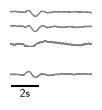

In [157]:
t_min, t_max = 1, 7  # s
X_TIME = np.arange(0, t_max - t_min, 1e-3)

fig = MultiPanel(grid=[1] * (nb_inputs + 2), figsize=figsize_inputs, hspace=0, wspace=0)
for idx, ax in enumerate(fig.panels):
    ax.axis('off')
    if idx not in (nb_inputs - 1, nb_inputs + 1):
        ax.plot(X_TIME, inputs[int(t_min / 1e-3):int(t_max / 1e-3), idx], linewidth=linewidth, color=color_inputs)
    ax.set_xlim(0, X_TIME.max())
add_scalebar(fig.panels[-1], matchx=False, matchy=False, sizex=2.0, sizey=0, labelx='2s',
             loc='lower left', barwidth=1.5, pad=0, sep=2)

plt.savefig(fig9_dir / 'b_inputs.pdf', bbox_inches='tight')
plt.show()

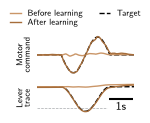

In [158]:
t_min, t_max = 1, 5  # s
X_TIME = np.arange(0, t_max - t_min, 1e-3)
window = slice(int(t_min / 1e-3), int(t_max / 1e-3))

fig = MultiPanel(grid=[1, 1], figsize=figsize_targets, hspace=0, wspace=0, height_ratios=[1, 0.75])
for ax, label in zip(fig.panels, ['Motor\ncommand', 'Lever\ntrace']):
    ax.spines['bottom'].set_visible(False)
    ax.xaxis.set_ticks([])
    ax.spines['left'].set_visible(False)
    ax.yaxis.set_ticks([])
    ax.set_ylabel(label, fontsize=6)
    ax.set_xlim(0, X_TIME.max())

fig.panels[0].plot(X_TIME, motor_before[window], linewidth=linewidth, color=color_lever_light)
fig.panels[0].plot(X_TIME, motor_after[window], linewidth=linewidth, color=color_lever)
fig.panels[0].plot(X_TIME, motor_target[window], linewidth=linewidth, color='black', ls='dashed', zorder=0)

fig.panels[1].plot(X_TIME, lever_target[window], linewidth=linewidth, color='black', ls='dashed')
fig.panels[1].plot(X_TIME, lever_before[window], linewidth=linewidth, color=color_lever_light)
fig.panels[1].plot(X_TIME, lever_after[window], linewidth=linewidth, color=color_lever)
fig.panels[1].hlines(LEVER_THRESHOLD, 0, 2.9, color='#A7A9AC', linestyle='--', linewidth=0.5, zorder=0)
add_scalebar(fig.panels[1], matchx=False, matchy=False, sizex=1.0, sizey=0, labelx='1s',
             loc='lower right', barwidth=1.5, pad=0, sep=2, hidey=False)

fig.fig.legend(['Before learning', 'After learning', 'Target'], loc='lower center', bbox_to_anchor=(0.5, 1.0),
               ncol=2, fontsize=6, frameon=False, handlelength=1.3, handleheight=0.5, borderpad=0, labelspacing=0.2)

plt.savefig(fig9_dir / 'b_motor_lever.pdf', bbox_inches='tight')
plt.show()

### Panel c: correct trials during learning

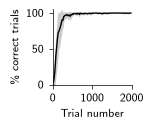

In [159]:
correct = (lever_minimums < LEVER_THRESHOLD).reshape(len(lever_minimums), -1, TRIALS_PER_BIN).mean(-1)  # [networks, bins]
x_bins = np.arange(correct.shape[1])

fig, ax = plt.subplots(1, 1, figsize=panelsize_performance)
ax.plot(x_bins, correct.mean(0), color='black', linewidth=linewidth)
ax.fill_between(x_bins, correct.mean(0) - correct.std(0), correct.mean(0) + correct.std(0),
                color='black', alpha=0.2, lw=0)
ax.set_xlim(0, x_bins[-1] + 1)
ax.set_ylabel(r'\% correct trials')
ax.set_xlabel('Trial number')
ax.set_ylim(0, 1.05)
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(['0', '50', '100'])
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(['0', '1000', '2000'])

plt.savefig(fig9_dir / 'c_correct_trials.pdf', bbox_inches='tight')
plt.show()

### Panels e, g: Type 2 interneuron activity and feedback during movement

In [171]:
def data_bins_per_xlim(x_hist, xlim):
    """How many digitized data bins fit across the data panel's x-range."""
    bin_width = (x_hist.max() - x_hist.min()) / (len(x_hist) - 1)
    return (xlim[1] - xlim[0]) / bin_width


panels = [
    # name, [networks, recordings, neurons], color, xmin, ylabel, ylim, yticks, xlabel_hist, xlim_hist, xticks_hist, xticklabels_hist,
    # bins_per_xlim (matched to the data histogram of panel f / h)
    ('e_type2', i2_act, color_inh2, 0, 'Mean activity', (0.95, 1.15), [1, 1.1], 'Activity change', (-0.8, 0.8), [-0.8, 0, 0.8], ['-0.5', '0', '0.5'],
     data_bins_per_xlim(x_som_hist, (-1.2, 1.2))),
    ('g_feedback', mean_fb, color_closedloop, -50, 'Mean feedback', (0, 1.5), [0, 1], 'Feedback change', (-0.7, 0.7), [-0.7, 0, 0.7], ['-0.4', '0', '0.4'],
     data_bins_per_xlim(x_vip_hist, (-2, 2))),
]

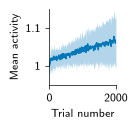

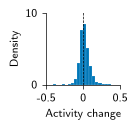

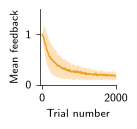

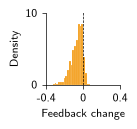

In [173]:
for name, act, color, xmin, ylabel, ylim, yticks, xlabel_hist, xlim_hist, xticks_hist, xticklabels_hist, bins_per_xlim in panels:
    # network mean, normalized to the first trial
    act_avg = act.mean(-1)
    act_avg = act_avg / act_avg[:, :1]

    fig, ax = plt.subplots(1, 1, figsize=panelsize_other)
    ax.plot(X_TRIALS, act_avg.mean(0), color=color, linewidth=linewidth)
    ax.fill_between(X_TRIALS, act_avg.mean(0) - act_avg.std(0), act_avg.mean(0) + act_avg.std(0),
                    color=color, alpha=0.3, lw=0)
    ax.set_xlim(xmin, X_TRIALS[-1] + 1)
    ax.set_xticks([0, 2000])
    ax.set_xticklabels(['0', '2000'])
    ax.set_xlabel('Trial number')
    ax.set_ylabel(ylabel)
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{t:g}' for t in yticks])
    plt.savefig(fig9_dir / f'{name}.pdf', bbox_inches='tight')
    plt.show()

    # last minus first trial, all neurons of all networks
    act_change = (act[:, -1] - act[:, 0]).flatten()
    # same bin width relative to X axis range as in data
    bin_width = (xlim_hist[1] - xlim_hist[0]) / bins_per_xlim
    bin_edges = np.arange(np.floor(act_change.min() / bin_width), np.ceil(act_change.max() / bin_width) + 1) * bin_width

    fig, ax = plt.subplots(1, 1, figsize=panelsize_other)
    ax.hist(act_change, bins=bin_edges, color=color, edgecolor='white', linewidth=0.1, density=True, alpha=1.0)
    ax.vlines(0, 0, 10, color='black', linestyle='--', linewidth=0.5)
    ax.set_xlabel(xlabel_hist)
    ax.set_ylabel('Density')
    ax.set_xlim(*xlim_hist)
    ax.set_ylim(0, 5)
    ax.set_xticks(xticks_hist)
    ax.set_xticklabels(xticklabels_hist)
    ax.set_yticks([0, 5])
    ax.set_yticklabels(['0', '10'])
    plt.savefig(fig9_dir / f'{name}_hist.pdf', bbox_inches='tight')
    plt.show()